## HOSVD+GPR vs POD+GPR — ZOU_GPR Dataset

Direct adaptation of `NON_SI_SA_MAI/isacco.ipynb` to the ZOU_GPR dataset.

**Dataset:** 23 CFD combustion cases (CH4/H2/N2 fuel jet), 2 parameters: Re ∈ {11k–19k}, Y_H2 ∈ {0.04–0.20}.  
**Grid:** 84 radial × 101 axial → 8484 cells.  
**Strategy:** Leave-one-out (LOO) on simulations — for each case, train on the other 22, predict the held-out one.  
**Preprocessing:** `log1p` applied to the 8 species; T and Uz kept linear. Per-fold z-score standardisation before decomposition.  
**HOSVD:** 3-D Tucker on `(n_cells, n_feat, n_train)`, cells compressed to `R_CELLS`, 2-D GPR on (Re, Y_H2) to predict the simulation factor-matrix row.  
**POD:** flatten to `(n_cells × n_feat, n_train)`, SVD, 2-D GPR on (Re, Y_H2) on the POD coefficients.  
**Metric:** NRMSE per feature (computed in log1p space for species, linear for T/Uz).

In [1]:
import sys
sys.path.insert(0, '/home/isacco/PROJECTS/NON_SI_SA_MAI')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from utils import compute_factor, compute_core
from pathlib import Path
import csv

DATA_DIR  = Path('/home/isacco/DATA/ZOU_GPR')
CASES_DIR = DATA_DIR / 'Datasets_Isacco'

R_CELLS = 30   # cells compressed to this rank (same as isacco.ipynb)

_ALL_COLS = [
    'x','y','z','alphat',
    'C2H','C2H2','C2H3','C2H4','C2H5','C2H6','C3H7','C3H8',
    'CH','CH2','CH2CHO','CH2CO','CH2O','CH2OH','CH2S','CH3','CH3CHO','CH3O','CH3OH',
    'CH4','CO','CO2','epsilon','H','H2','H2O','H2O2','HCCO','HCCOH','HCO','HO2',
    'k','N2','O2','OH','p','T','Ux','Uy','Uz'
]
_CI = {name: i for i, name in enumerate(_ALL_COLS)}
print('Imports OK')

Imports OK


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
features     = ['CH4', 'CO', 'CO2', 'H2', 'H2O', 'N2', 'O2', 'OH', 'T', 'Uz']
feat_indices = [_CI[f] for f in features]
n_feat       = len(features)
n_log1p      = 8   # first 8 features are species → apply log1p

FEAT_LABELS  = ['CH$_4$', 'CO', 'CO$_2$', 'H$_2$', 'H$_2$O',
                'N$_2$', 'O$_2$', 'OH', 'T', 'U$_z$']

def load_case(path):
    raw    = np.loadtxt(path, skiprows=1)
    x_vals = np.unique(raw[:, _CI['x']])
    z_vals = np.unique(raw[:, _CI['z']])
    idx    = np.lexsort((raw[:, _CI['x']], raw[:, _CI['z']]))
    grid   = raw[idx].reshape(len(z_vals), len(x_vals), len(_ALL_COLS))
    return grid, x_vals, z_vals

with open(DATA_DIR / 'case_summary.csv') as f:
    all_rows = list(csv.DictReader(f))

available = {p.stem for p in CASES_DIR.glob('*.xy')}
rows = [r for r in all_rows if r['case_name'] in available]
rows.sort(key=lambda r: int(r['case_id']))

n_sim = len(rows)
P     = np.array([[float(r['Re']), float(r['Y_H2'])] for r in rows])   # (n_sim, 2)

_g0, x_vals, z_vals = load_case(CASES_DIR / (rows[0]['case_name'] + '.xy'))
n_z, n_x = len(z_vals), len(x_vals)
n_cells  = n_z * n_x

# Build raw tensor (n_sim, n_feat, n_z, n_x)
tensor_raw = np.zeros((n_sim, n_feat, n_z, n_x))
for i, row in enumerate(rows):
    g, _, _ = load_case(CASES_DIR / (row['case_name'] + '.xy'))
    for j, fi in enumerate(feat_indices):
        tensor_raw[i, j, :, :] = g[:, :, fi]

# log1p on species, reshape → (n_cells, n_feat, n_sim)
tensor_log = tensor_raw.copy()
tensor_log[:, :n_log1p, :, :] = np.log1p(tensor_log[:, :n_log1p, :, :])

X3 = tensor_log.reshape(n_sim, n_feat, n_cells).transpose(2, 1, 0)  # (n_cells, n_feat, n_sim)

print(f'X3 shape: {X3.shape}   (n_cells={n_cells}, n_feat={n_feat}, n_sim={n_sim})')
print(f'P shape:  {P.shape}   Re ∈ [{P[:,0].min():.0f}, {P[:,0].max():.0f}]  '
      f'Y_H2 ∈ [{P[:,1].min():.2f}, {P[:,1].max():.2f}]')

X3 shape: (8484, 10, 23)   (n_cells=8484, n_feat=10, n_sim=23)
P shape:  (23, 2)   Re ∈ [11000, 19000]  Y_H2 ∈ [0.04, 0.20]


In [3]:
# ── LOO: HOSVD+GPR vs POD+GPR ──────────────────────────────────────────────────
def minmax_norm(arr_tr, val):
    """Scale val using training range; returns float in [0,1] (extrapolation possible)."""
    lo, hi = arr_tr.min(), arr_tr.max()
    return (val - lo) / (hi - lo) if hi > lo else 0.0

kern = ConstantKernel() * Matern(nu=2.5)

X_true = X3.copy()                        # (n_cells, n_feat, n_sim) — log1p space
X_hsvd = np.zeros_like(X_true)
X_pod  = np.zeros_like(X_true)

for i_te in range(n_sim):
    tr    = [j for j in range(n_sim) if j != i_te]
    n_tr  = len(tr)
    X_tr  = X3[:, :, tr]                  # (n_cells, n_feat, n_tr)

    # per-fold standardisation
    mu  = X_tr.mean(axis=(0, 2))           # (n_feat,)
    sig = X_tr.std( axis=(0, 2));  sig[sig == 0] = 1.
    scale   = lambda X: (X - mu[None, :, None]) / sig[None, :, None]
    unscale = lambda X:  X * sig[None, :]  + mu[None, :]   # X: (n_cells, n_feat)

    X_tr_s = scale(X_tr)                   # (n_cells, n_feat, n_tr)

    # minmax-normalised GPR inputs
    Re_tr   = P[tr, 0];  YH2_tr = P[tr, 1]
    P_tr_nm = np.column_stack([
        (Re_tr  - Re_tr.min())  / (Re_tr.max()  - Re_tr.min()),
        (YH2_tr - YH2_tr.min()) / (YH2_tr.max() - YH2_tr.min()),
    ])                                      # (n_tr, 2)
    P_te_nm = np.array([[
        minmax_norm(Re_tr,  P[i_te, 0]),
        minmax_norm(YH2_tr, P[i_te, 1]),
    ]])                                     # (1, 2)

    # ── HOSVD 3D ────────────────────────────────────────────────────────────────
    Uc = compute_factor(X_tr_s, mode=0)[:, :R_CELLS]   # (n_cells, R_CELLS)
    Uf = compute_factor(X_tr_s, mode=1)                 # (n_feat,  n_feat)
    Us = compute_factor(X_tr_s, mode=2)                 # (n_tr,    n_tr)
    Gc = compute_core(X_tr_s, [Uc, Uf, Us])             # (R_CELLS, n_feat, n_tr)

    # sign consistency so GPR sees a smooth manifold in parameter space
    for r in range(Us.shape[1]):
        if Us[0, r] < 0:
            Us[:, r] *= -1;  Gc[:, :, r] *= -1

    gpr_h = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, normalize_y=True)
    gpr_h.fit(P_tr_nm, Us)
    alpha = gpr_h.predict(P_te_nm).squeeze()            # (n_tr,)

    Z = np.einsum('abc,c->ab', Gc, alpha)               # (R_CELLS, n_feat)
    X_hsvd[:, :, i_te] = unscale(Uc @ Z @ Uf.T)

    # ── POD + 2D GPR ────────────────────────────────────────────────────────────
    mat_tr  = X_tr_s.reshape(n_cells * n_feat, n_tr)    # (n_cells*n_feat, n_tr)
    V, _, _ = np.linalg.svd(mat_tr, full_matrices=False)
    r_pod   = min(R_CELLS, V.shape[1])
    V       = V[:, :r_pod]
    a_tr    = (V.T @ mat_tr).T                           # (n_tr, r_pod)

    gpr_p = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, normalize_y=True)
    gpr_p.fit(P_tr_nm, a_tr)
    a_te  = gpr_p.predict(P_te_nm).squeeze()             # (r_pod,)
    X_pod[:, :, i_te] = unscale((V @ a_te).reshape(n_cells, n_feat))

    print(f'  sim {i_te:2d}  Re={P[i_te,0]:.0f}  Y_H2={P[i_te,1]:.2f}  done')

/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  sim  0  Re=11000  Y_H2=0.04  done


/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  sim  1  Re=13000  Y_H2=0.04  done


/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  sim 20  Re=15000  Y_H2=0.20  done


/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  sim 21  Re=17000  Y_H2=0.20  done
  sim 22  Re=19000  Y_H2=0.20  done


/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/isacco/miniconda3/envs/isi/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [4]:
# ── NRMSE per feature ──────────────────────────────────────────────────────────
def nrmse_per_feat(pred, true):
    out = []
    for f in range(true.shape[1]):
        d   = (pred[:, f, :] - true[:, f, :]).ravel()
        rng = float(true[:, f, :].max() - true[:, f, :].min())
        out.append(np.sqrt(np.mean(d**2)) / rng if rng > 0 else 0.)
    return np.array(out)

err_h = nrmse_per_feat(X_hsvd, X_true)
err_p = nrmse_per_feat(X_pod,  X_true)
print(f'mean NRMSE — HOSVD: {err_h.mean():.4f}   POD: {err_p.mean():.4f}')
for f, (eh, ep) in enumerate(zip(err_h, err_p)):
    print(f'  {features[f]:6s}  HOSVD={eh:.4f}  POD={ep:.4f}')

mean NRMSE — HOSVD: 0.0551   POD: 0.0551
  CH4     HOSVD=0.0117  POD=0.0116
  CO      HOSVD=0.0465  POD=0.0465
  CO2     HOSVD=0.0882  POD=0.0882
  H2      HOSVD=0.0537  POD=0.0537
  H2O     HOSVD=0.0740  POD=0.0740
  N2      HOSVD=0.0539  POD=0.0539
  O2      HOSVD=0.0511  POD=0.0510
  OH      HOSVD=0.0760  POD=0.0760
  T       HOSVD=0.0566  POD=0.0565
  Uz      HOSVD=0.0396  POD=0.0396


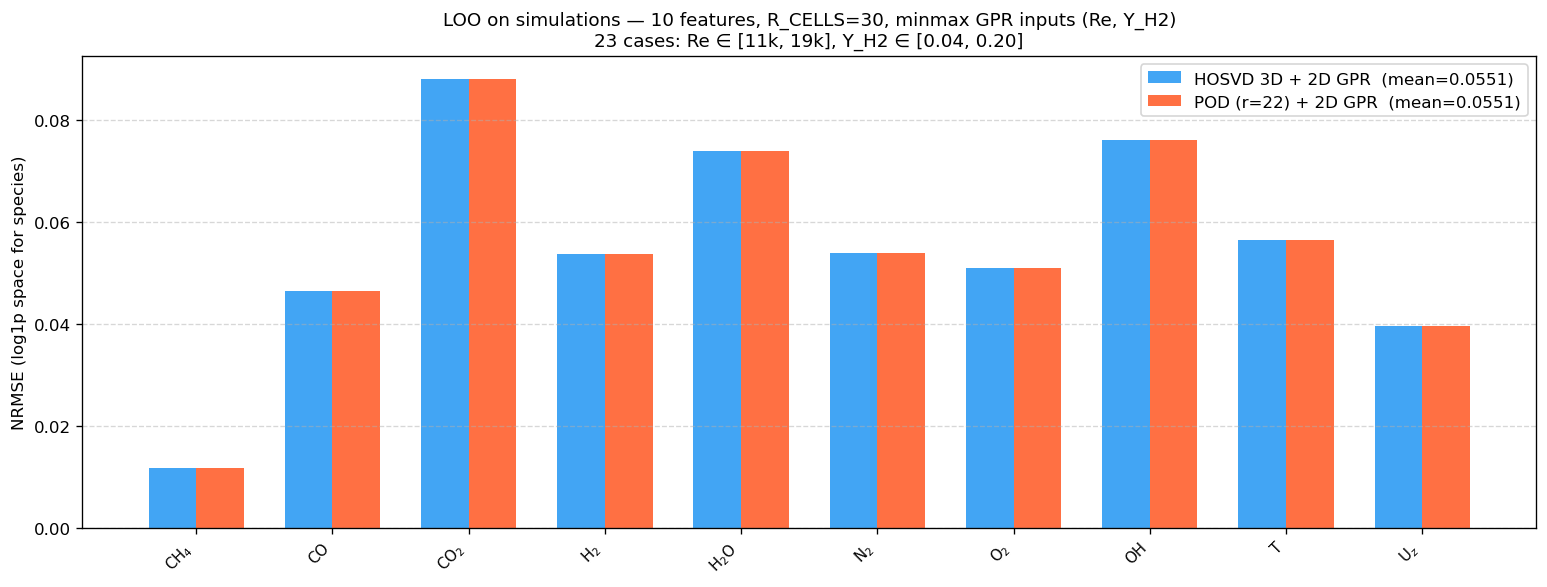

In [5]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
x = np.arange(n_feat);  w = 0.35
fig, ax = plt.subplots(figsize=(13, 5), dpi=120)
ax.bar(x - w/2, err_h, w, color='#2196F3', alpha=0.85,
       label=f'HOSVD 3D + 2D GPR  (mean={err_h.mean():.4f})')
ax.bar(x + w/2, err_p, w, color='#FF5722', alpha=0.85,
       label=f'POD (r={r_pod}) + 2D GPR  (mean={err_p.mean():.4f})')
ax.set_xticks(x)
ax.set_xticklabels(FEAT_LABELS, fontsize=9, rotation=45, ha='right')
ax.set_ylabel('NRMSE (log1p space for species)')
ax.set_title(f'LOO on simulations — 10 features, R_CELLS={R_CELLS}, minmax GPR inputs (Re, Y_H2)\n'
             f'{n_sim} cases: Re ∈ [11k, 19k], Y_H2 ∈ [0.04, 0.20]', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

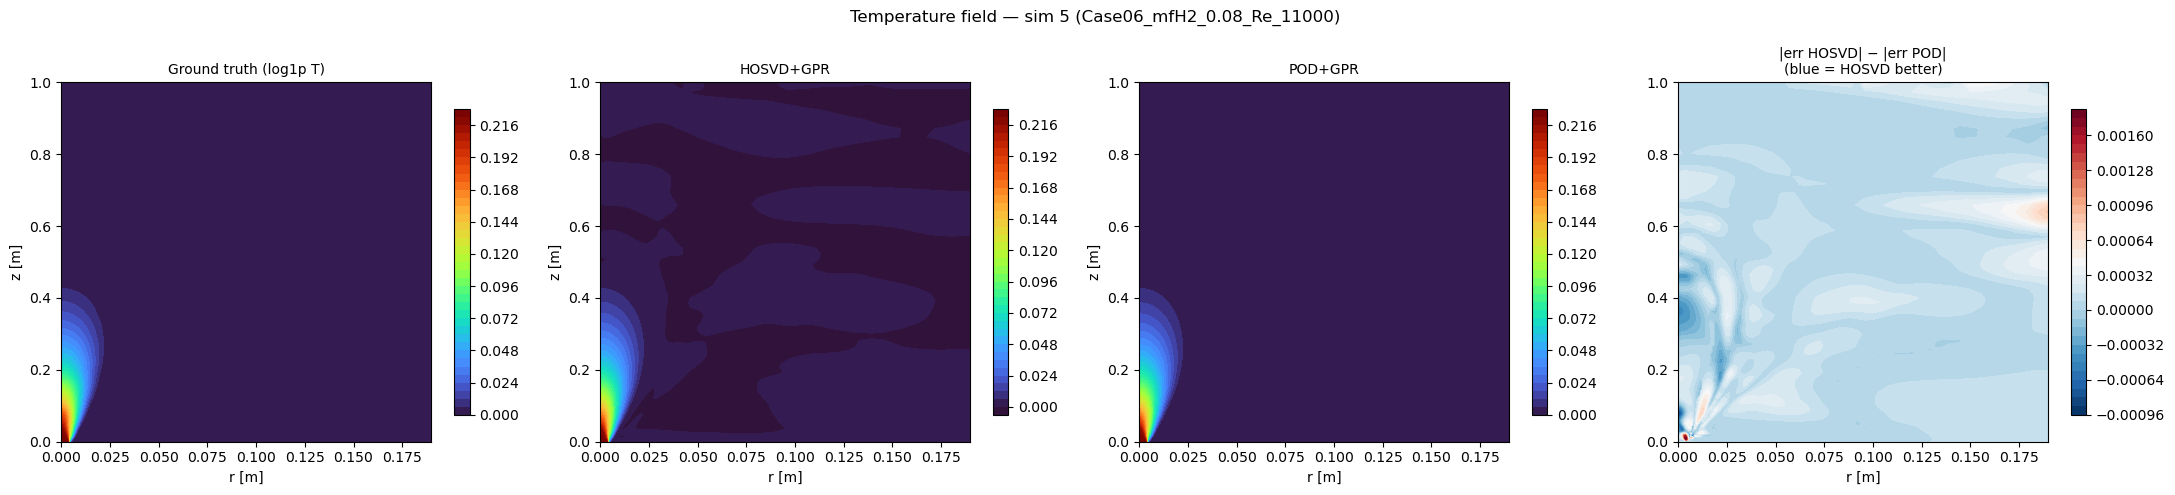

In [8]:
# ── Visual comparison — T field for one test simulation ────────────────────────
i_show   = 5                        # pick a test simulation
f_show   = features.index('CH4')

T_true = X_true[:, f_show, i_show].reshape(n_z, n_x)
T_hsvd = X_hsvd[:, f_show, i_show].reshape(n_z, n_x)
T_pod  = X_pod [:, f_show, i_show].reshape(n_z, n_x)

vmin = min(T_true.min(), T_hsvd.min(), T_pod.min())
vmax = max(T_true.max(), T_hsvd.max(), T_pod.max())
XX, ZZ = np.meshgrid(x_vals, z_vals)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, data, title in zip(
    axes[:3],
    [T_true, T_hsvd, T_pod],
    ['Ground truth (log1p T)', 'HOSVD+GPR', 'POD+GPR']
):
    cf = ax.contourf(XX, ZZ, data, levels=40, cmap='turbo', vmin=vmin, vmax=vmax)
    plt.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('r [m]');  ax.set_ylabel('z [m]')

err_h_field = np.abs(T_hsvd - T_true)
err_p_field = np.abs(T_pod  - T_true)
vmax_err = max(err_h_field.max(), err_p_field.max())
cf4 = axes[3].contourf(XX, ZZ, err_h_field - err_p_field, levels=40, cmap='RdBu_r')
plt.colorbar(cf4, ax=axes[3], shrink=0.85)
axes[3].set_title('|err HOSVD| − |err POD|\n(blue = HOSVD better)', fontsize=10)
axes[3].set_xlabel('r [m]')

case_name = rows[i_show]['case_name']
fig.suptitle(f'Temperature field — sim {i_show} ({case_name})', fontsize=12)
plt.tight_layout()
plt.show()

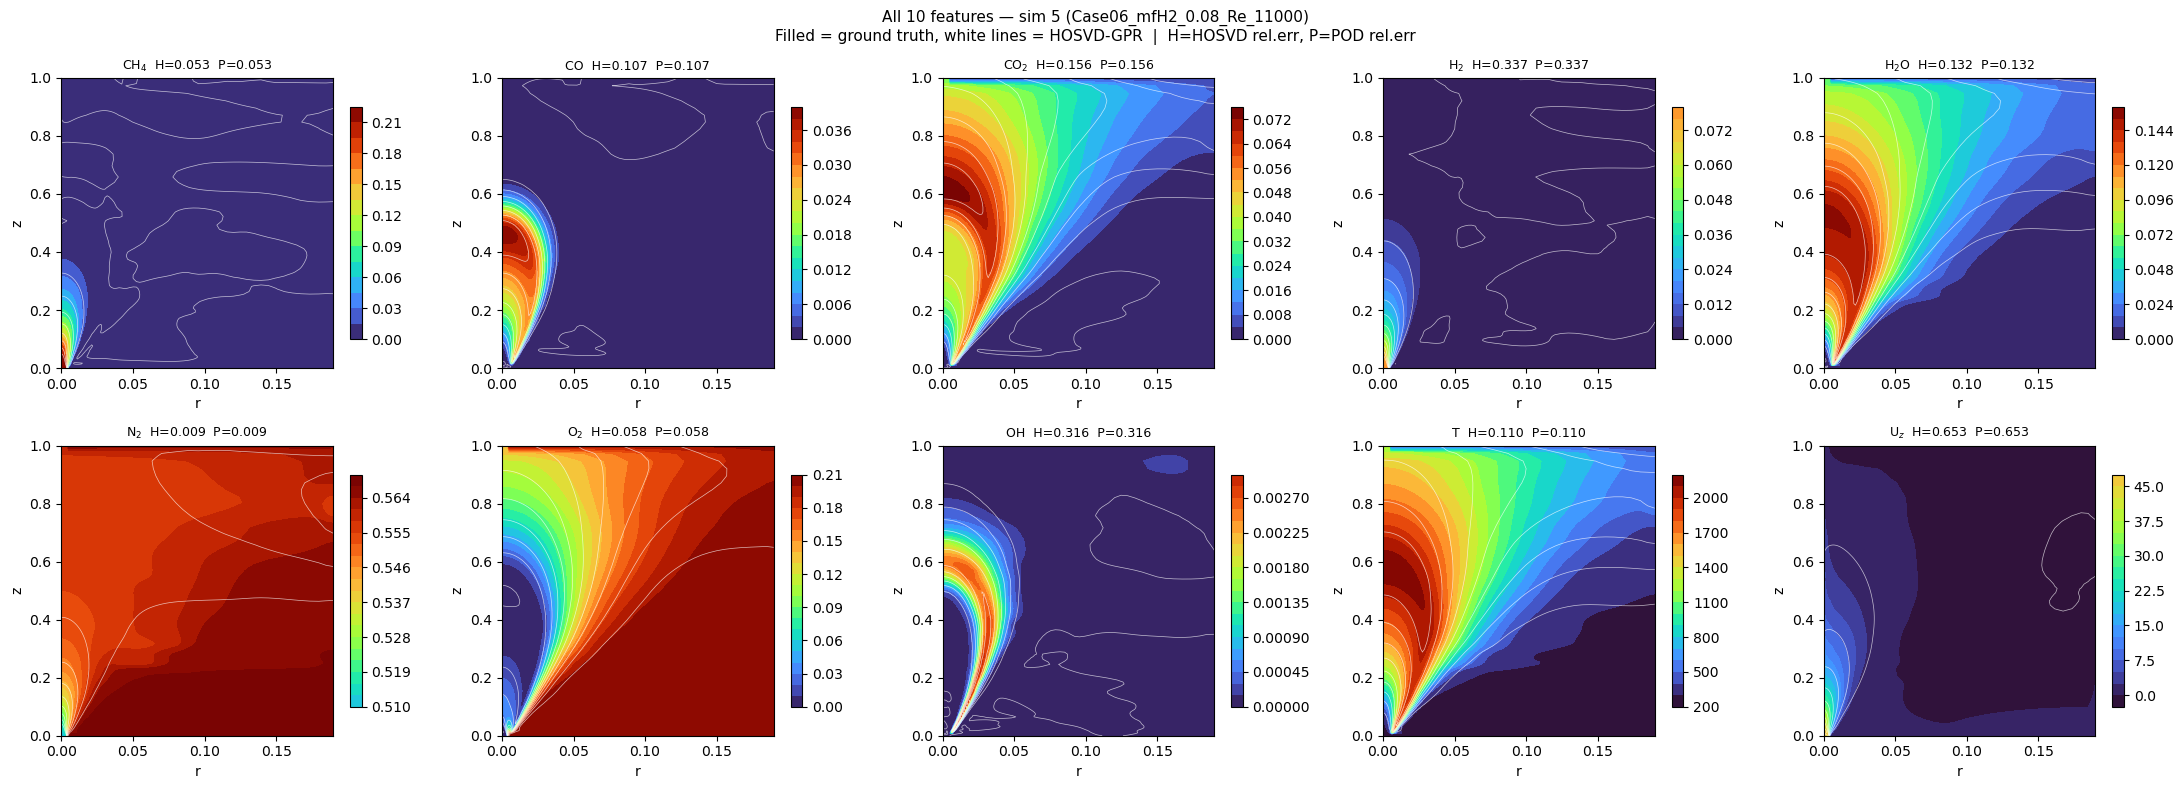

In [7]:
# ── All 10 features for the same test simulation ───────────────────────────────
def rel_err(pred, true):
    return np.linalg.norm(pred - true) / np.linalg.norm(true)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for j, (ax, fname, flabel) in enumerate(zip(axes.ravel(), features, FEAT_LABELS)):
    true_f = X_true[:, j, i_show].reshape(n_z, n_x)
    hsvd_f = X_hsvd[:, j, i_show].reshape(n_z, n_x)
    vmin_f = min(true_f.min(), hsvd_f.min())
    vmax_f = max(true_f.max(), hsvd_f.max())
    cf = ax.contourf(XX, ZZ, true_f, levels=20, cmap='turbo', vmin=vmin_f, vmax=vmax_f)
    ax.contour(XX, ZZ, hsvd_f, levels=10, colors='white', linewidths=0.5, alpha=0.7)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    reh = rel_err(X_hsvd[:, j, i_show], X_true[:, j, i_show])
    rep = rel_err(X_pod [:, j, i_show], X_true[:, j, i_show])
    ax.set_title(f'{flabel}  H={reh:.3f}  P={rep:.3f}', fontsize=9)
    ax.set_xlabel('r');  ax.set_ylabel('z')

fig.suptitle(f'All 10 features — sim {i_show} ({case_name})\n'
             f'Filled = ground truth, white lines = HOSVD-GPR  |  H=HOSVD rel.err, P=POD rel.err',
             fontsize=11)
plt.tight_layout()
plt.show()